In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import numpy as np

plt.rcParams['figure.figsize'] = [10, 8]
np.random.seed(42)

In [2]:
large = 27; med = 18; small = 12
l_width = 3; m_width = 1.5; s_width = 0.7
params = {'axes.titlesize': large,
          'legend.fontsize': large,
          'legend.title_fontsize':large,
          'figure.figsize': (8, 5),
          'axes.labelsize': large,
          'xtick.labelsize': med,
          'ytick.labelsize': med,
          'figure.titlesize': large,
          'lines.linewidth': l_width,
          'lines.markersize': 10,
          'axes.linewidth': l_width,
          'xtick.major.size': 8,
          'ytick.major.size': 8,
          'xtick.minor.size': 4,
          'ytick.minor.size': 4,
          'xtick.major.width': m_width,
          'ytick.major.width': m_width,
          'xtick.minor.width': s_width,
          'ytick.minor.width': s_width,
          'grid.linewidth': m_width}
plt.rcParams.update(params)



In [3]:
df_esm=pd.read_csv('./ESM/structure_metrics.csv')
df_esm.head()
print(df_esm.shape[0])

10000


In [4]:
df_ss=pd.read_csv('/Users/mshekhar/Desktop/Projects/Nanobody/Library_Design/ESM/design_fold/ss_predictions.csv')
df_ss["sample_id"]=df_ss["sample"]
df_ss.head()

,sample,length,pct_helix,pct_strand,pct_coil,pct_structured,ss3,sample_id
0,sample_1,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...,sample_1
1,sample_10,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...,sample_10
2,sample_100,78,0.0,57.7,42.3,57.7,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCEEEEEEEECCEEEE...,sample_100
3,sample_1000,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...,sample_1000
4,sample_10000,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...,sample_10000


In [5]:
df_scores= pd.read_csv('./Sequence_Design/designs/seqs/scores_metadata.txt',delimiter="\t")
df_scores = df_scores.iloc[1:]
df_scores["sample_id"]=['sample_'+str(int(x)) for x in df_scores["sample_id"]]
print(df_scores.shape[0])
df_scores.head()

10000


,sample_id,score,global_score,seq_recovery
1,sample_1,0.7245,0.8066,0.5205
2,sample_2,0.7180,0.8091,0.5342
3,sample_3,0.6937,0.7878,0.4932
4,sample_4,0.7068,0.7888,0.4795
5,sample_5,0.7037,0.7823,0.5205


In [6]:
df=pd.merge(df_scores, df_esm, on='sample_id')
df=pd.merge(df,df_ss,on="sample_id")

In [7]:
df.head()

,sample_id,score,global_score,seq_recovery,pLDDT,pTM,sample,length,pct_helix,pct_strand,pct_coil,pct_structured,ss3
0,sample_1,0.7245,0.8066,0.5205,90.8,0.852,sample_1,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
1,sample_2,0.7180,0.8091,0.5342,91.0,0.854,sample_2,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
2,sample_3,0.6937,0.7878,0.4932,90.4,0.837,sample_3,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
3,sample_4,0.7068,0.7888,0.4795,91.5,0.848,sample_4,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
4,sample_5,0.7037,0.7823,0.5205,90.3,0.840,sample_5,78,0.0,57.7,42.3,57.7,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCEEEEEEEECCEEEE...


# of sequences selected: 45


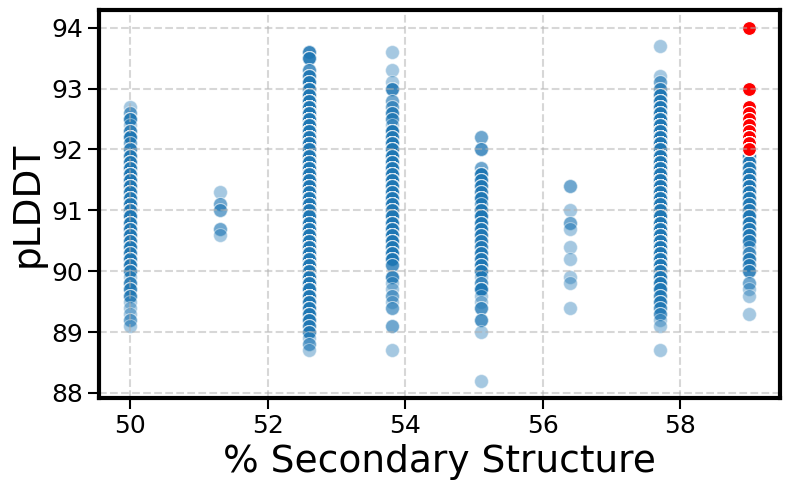

In [47]:
df_select=df[((df["pLDDT"]>=92) & (df["pct_structured"]>=58))]
sns.scatterplot(data=df,x='pct_structured',y='pLDDT',alpha=0.4)
plt.xlabel("% Secondary Structure")
sns.scatterplot(data=df_select,x='pct_structured',y='pLDDT',color="red")
plt.grid(lw=1.5,ls="--",alpha=0.5)
print ("# of sequences selected:",df_select.shape[0])
plt.tight_layout()
plt.savefig('selected.png')

In [45]:
df_select.head()

,sample_id,score,global_score,seq_recovery,pLDDT,pTM,sample,length,pct_helix,pct_strand,pct_coil,pct_structured,ss3
1017,sample_1018,0.7144,0.7972,0.5205,94.0,0.871,sample_1018,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
1841,sample_1842,0.7218,0.7997,0.5342,93.0,0.868,sample_1842,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
3325,sample_3326,0.7305,0.8226,0.5479,92.7,0.865,sample_3326,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
3752,sample_3753,0.6885,0.7706,0.5068,92.7,0.855,sample_3753,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
7166,sample_7167,0.7087,0.7982,0.4932,92.7,0.860,sample_7167,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...


In [46]:
df_select.to_csv('selected.txt')

In [ ]:
df

In [9]:
df=df.sort_values(by=["pTM"],ascending=False)
df.head()

,sample_id,score,global_score,seq_recovery,pLDDT,pTM,sample,length,pct_helix,pct_strand,pct_coil,pct_structured,ss3
1017,sample_1018,0.7144,0.7972,0.5205,94.0,0.871,sample_1018,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
1841,sample_1842,0.7218,0.7997,0.5342,93.0,0.868,sample_1842,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
8832,sample_8833,0.7337,0.8220,0.5890,92.6,0.867,sample_8833,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
4254,sample_4255,0.6962,0.7760,0.5205,92.8,0.867,sample_4255,78,0.0,57.7,42.3,57.7,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCEEEEEEEECCEEEE...
3794,sample_3795,0.7369,0.8244,0.5068,93.0,0.867,sample_3795,78,0.0,57.7,42.3,57.7,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCEEEEEEEECCEEEE...


In [10]:
df=df.sort_values(by=["pLDDT"],ascending=False)
df.head()

,sample_id,score,global_score,seq_recovery,pLDDT,pTM,sample,length,pct_helix,pct_strand,pct_coil,pct_structured,ss3
1017,sample_1018,0.7144,0.7972,0.5205,94.0,0.871,sample_1018,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
3057,sample_3058,0.6938,0.7844,0.5205,93.7,0.858,sample_3058,78,0.0,57.7,42.3,57.7,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCEEEEEEEECCEEEE...
9680,sample_9681,0.7251,0.8139,0.4932,93.6,0.866,sample_9681,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
9170,sample_9171,0.7235,0.8080,0.4658,93.6,0.864,sample_9171,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
1648,sample_1649,0.7031,0.7820,0.4795,93.6,0.862,sample_1649,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...


In [11]:
df.shape

(10000, 13)

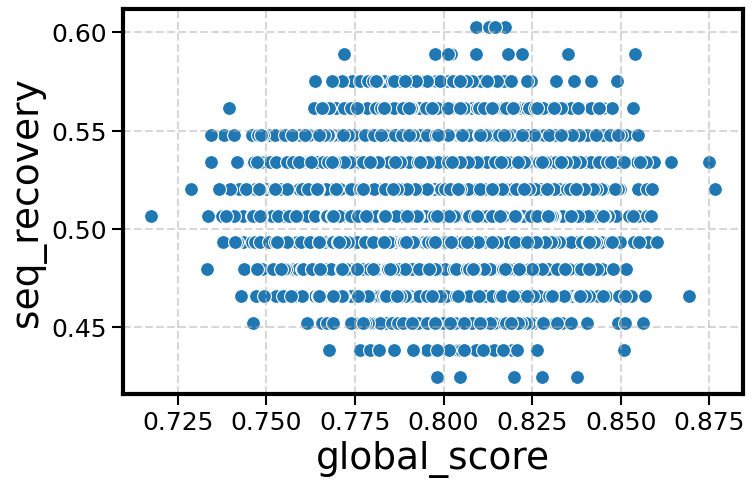

In [12]:
sns.scatterplot(data=df,x='global_score',y='seq_recovery')
plt.grid(lw=1.5,ls="--",alpha=0.5)

In [13]:
df_select=df[((df["pLDDT"]>=93) & (df["global_score"]>=0.80))]

In [14]:
df_select.shape

(17, 13)

In [15]:
df_select.head()

,sample_id,score,global_score,seq_recovery,pLDDT,pTM,sample,length,pct_helix,pct_strand,pct_coil,pct_structured,ss3
9680,sample_9681,0.7251,0.8139,0.4932,93.6,0.866,sample_9681,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
9170,sample_9171,0.7235,0.8080,0.4658,93.6,0.864,sample_9171,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
4248,sample_4249,0.7192,0.8038,0.5068,93.6,0.862,sample_4249,78,0.0,53.8,46.2,53.8,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCCCCCEEEECCEEEE...
9120,sample_9121,0.7065,0.8001,0.5068,93.2,0.862,sample_9121,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
488,sample_489,0.7228,0.8123,0.4795,93.2,0.857,sample_489,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...


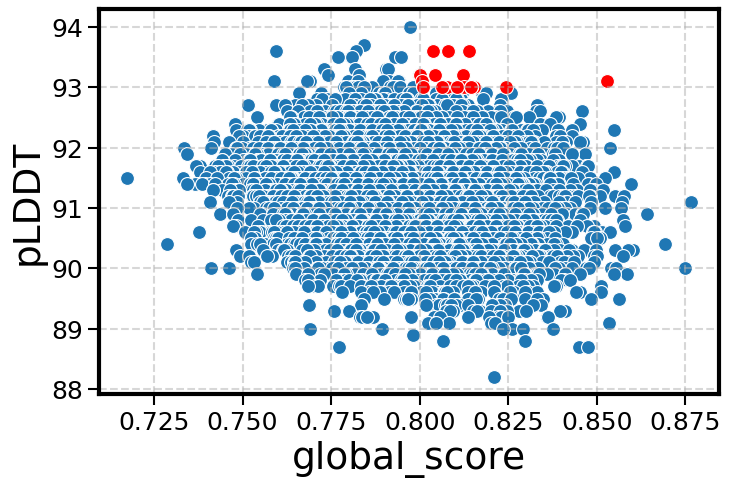

In [16]:
sns.scatterplot(data=df,x='global_score',y='pLDDT')
sns.scatterplot(data=df_select,x='global_score',y='pLDDT',color="red")
plt.grid(lw=1.5,ls="--",alpha=0.5)

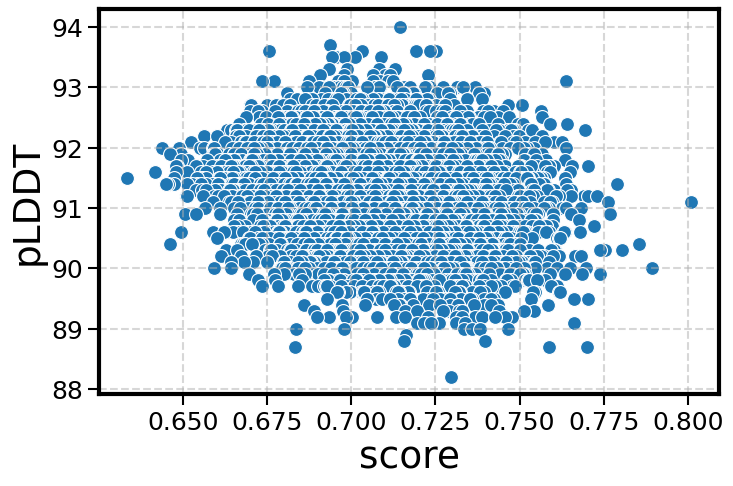

In [17]:
sns.scatterplot(data=df,x='score',y='pLDDT')
plt.grid(lw=1.5,ls="--",alpha=0.5)

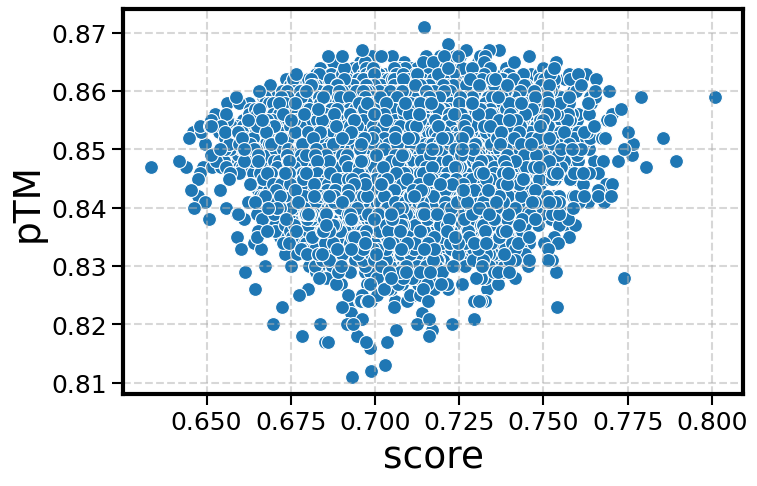

In [18]:
sns.scatterplot(data=df,x='score',y='pTM')
plt.grid(lw=1.5,ls="--",alpha=0.5)

Text(0, 0.5, 'Count')

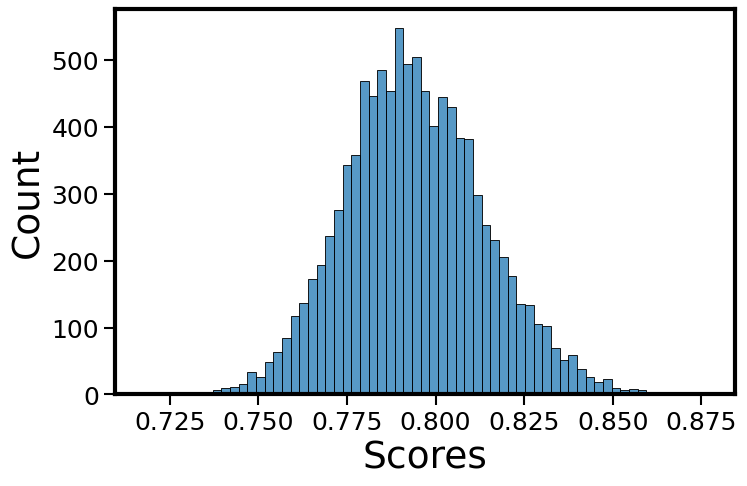

In [19]:
sns.histplot(df["global_score"])
plt.xlabel('Scores')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

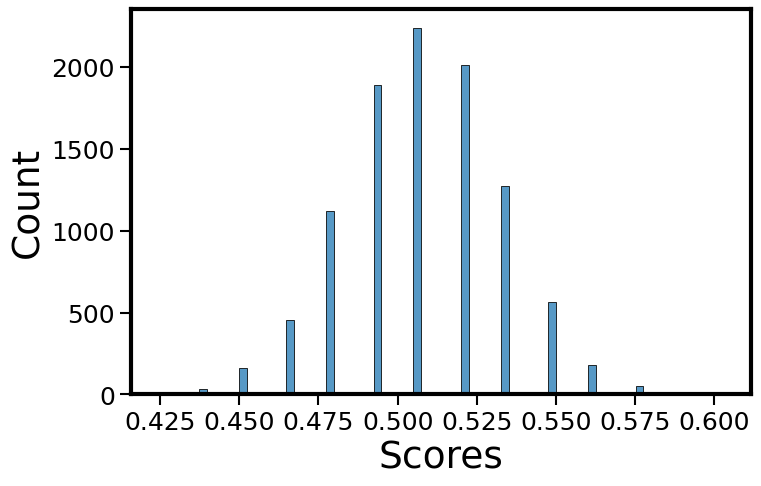

In [20]:
sns.histplot(df["seq_recovery"])
plt.xlabel('Scores')
plt.ylabel('Count')

In [21]:
import pandas as pd
df_ss=pd.read_csv('/Users/mshekhar/Desktop/Projects/Nanobody/Library_Design/ESM/design_fold/ss_predictions.csv')

In [22]:
df_ss.head()

,sample,length,pct_helix,pct_strand,pct_coil,pct_structured,ss3
0,sample_1,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
1,sample_10,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
2,sample_100,78,0.0,57.7,42.3,57.7,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCEEEEEEEECCEEEE...
3,sample_1000,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...
4,sample_10000,78,0.0,52.6,47.4,52.6,CCCEEEEEEEECCCCCCCCEEEEEEECCCCCCCCCCEEEECCEEEE...


<Axes: xlabel='pct_structured', ylabel='Count'>

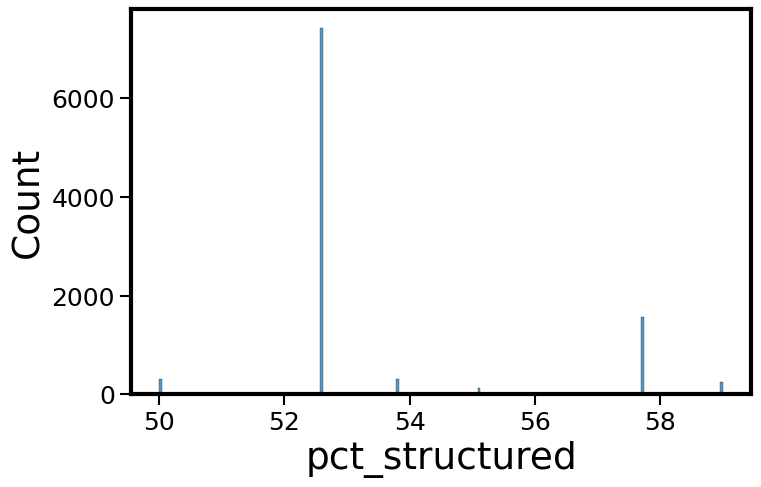

In [23]:
sns.histplot(df_ss["pct_structured"])

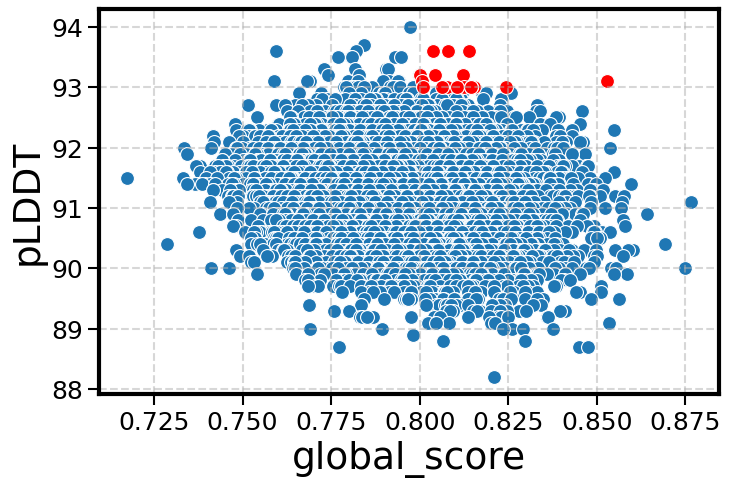

In [24]:
sns.scatterplot(data=df,x='global_score',y='pLDDT')
sns.scatterplot(data=df_select,x='global_score',y='pLDDT',color="red")
plt.grid(lw=1.5,ls="--",alpha=0.5)

In [25]:
df_select=df_ss[(df_ss["pct_structured"]>=59)]
df_select.shape

(248, 7)

In [26]:
df_select.head()

,sample,length,pct_helix,pct_strand,pct_coil,pct_structured,ss3
9,sample_1005,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
23,sample_1018,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
87,sample_1076,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
126,sample_1110,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
136,sample_112,78,0.0,59.0,41.0,59.0,CCCEEEEEEEECCCCCCCCEEEEEEEECCCCCEEEEEEEECCEEEE...
